In [1]:
import numpy as np
import gymnasium as gym
from gymnasium.spaces import Space
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import os, time
from IPython.display import clear_output
os.environ["SDL_VIDEODRIVER"] = "dummy"

import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from models import Qlearner, SARSA, eSARSA

# Environment

In [2]:
UP = 0; RIGHT = 1; DOWN = 2; LEFT = 3;

In [3]:
env = gym.make("CliffWalking-v1",render_mode="rgb_array")

In [4]:
def play_run(env,As,t_wait=0):
    env.reset()
    for Ai in As:
        s,R,terminated,truncated,info = env.step(Ai)
        clear_output(wait=True)
        plt.imshow(env.render())
        plt.axis('off')
        plt.show()
        time.sleep(t_wait)


# Optimal Solution from Classical Starting Point

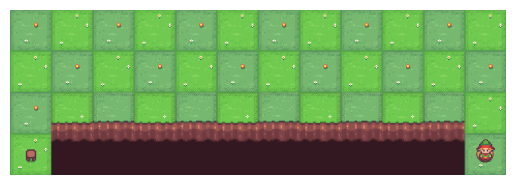

In [5]:
env.reset()
As = [UP] + [RIGHT]*11 + [DOWN]
play_run(env,As,t_wait=0.)

# Training Loop

In [6]:
def train_agent(env,agent,episodes=10):
    for i in range(episodes):
        s,_ = env.reset()
        done = False
        while not done:
            Ai = agent.act(str(s))
            s_,R,terminated,truncated,_ = env.step(Ai)
            Ai_ = agent.act(str(s_))
            agent.update_Q(s,s_,Ai,R,terminated,Ai_)
            s = s_
            done = terminated or truncated
    return agent

# SARSA vs Q-Learning vs E[SARSA]

## Running Individual Models

In [7]:
def do_run(env,Agent,a=0.2,g=0.80,e=0.2,episodes=10):
    agent = Agent(env.action_space,a,g,e)
    agent = train_agent(env=env,agent=agent,episodes=episodes)
    s,_ = env.reset()
    As = []; Rs = [];
    done = False
    while not done:
        Ai = agent.act(str(s))
        s,R,terminated,truncated,_ = env.step(Ai)
        As += [Ai]; Rs += [R]
        done = terminated or truncated
    return As,Rs

### SARSA

In [ ]:
As,Rs = do_run(env,SARSA)
play_run(env,As)

### Q Learning

### E[SARSA]

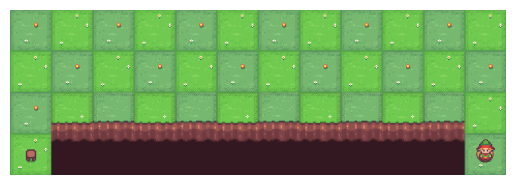

In [8]:
As,Rs = do_run(env,eSARSA)
play_run(env,As)

## Model Comparison